In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('spam.csv', encoding='latin-1')   #import spam.csv file and encoding tells pandas how to interpret characters
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
df.shape

(5572, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.sample(5)  # this displays 5 random data rows, it is different from df.head() that displays only first five rows

,v1,v2
1320,ham,Just sent again. Do you scream and moan in bed...
2073,spam,FreeMsg: Claim ur 250 SMS messages-Text OK to ...
3155,ham,Long time. You remember me today.
9,spam,Had your mobile 11 months or more? U R entitle...
1226,spam,Reply with your name and address and YOU WILL ...


In [7]:
df.rename(columns={"v1":"target", "v2":"text"}, inplace=True)  # rename columns v1 and v2 as target and text respectively
df.sample(5)

,target,text
2463,ham,"Good afternoon, babe. How goes that day ? Any ..."
4360,ham,"Don't Think About \What u Have Got\"" Think Abo..."
3505,ham,Nite...
3832,ham,I had askd u a question some hours before. Its...
1819,ham,Dunno dat's wat he told me. Ok lor...


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["target"])   # this code converts ham into 0 and spam into 1(as computer learns only numbers )
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.isnull().sum()   # counts missing values in target and text

,0
target,0
text,0


In [10]:
df.duplicated().sum()    # it checks total number of duplicate rows


np.int64(403)

In [11]:
df = df.drop_duplicates(keep="first") #If the same complete row occurs more than once, keep the first occurrence and remove the remaining copies.
df.duplicated().sum()   # this has removed all duplicates rows

np.int64(0)

In [12]:
df.shape

(5169, 2)

**Exploratory Data Analysis (EDA)**
Before training the model, we investigate and understand the data.
We ask questions such as:

How many Ham messages?
How many Spam messages?
Are the classes balanced?
How long are the messages?
How many words do messages contain?

In [13]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df["target"].value_counts()    #There are many more Ham messages than Spam messages.

,count
target,
0,4516
1,653


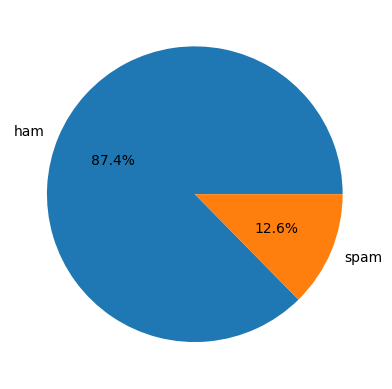

In [15]:
plt.pie(df["target"].value_counts(), labels=["ham", "spam"], autopct="%1.1f%%")
plt.show()      #This creates a pie chart showing the proportion of ham and spam msgs

In [16]:
import nltk    #natural language toolkits

In [17]:
nltk.download("punkt")   #  it provides for processing human language, A tokenizer breaks text into smaller pieces called tokens.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [18]:
df["text"].apply(len)    # counted length of letters of all sentences in row with index 0, then row2 and so on

,text
0,111
1,29
2,155
3,49
4,61
...,...
5567,161
5568,37
5569,57
5570,125


In [19]:
df['num_charaters'] =df['text'].apply(len)
df.head()

,target,text,num_charaters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
nltk.download('punkt_tab')
df['text'].apply(lambda x : nltk.word_tokenize(x))    # it tokenize the sentences (into pieces)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text
0,"[Go, until, jurong, point, ,, crazy, .., Avail..."
1,"[Ok, lar, ..., Joking, wif, u, oni, ...]"
2,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,"[U, dun, say, so, early, hor, ..., U, c, alrea..."
4,"[Nah, I, do, n't, think, he, goes, to, usf, ,,..."
...,...
5567,"[This, is, the, 2nd, time, we, have, tried, 2,..."
5568,"[Will, Ì_, b, going, to, esplanade, fr, home, ?]"
5569,"[Pity, ,, *, was, in, mood, for, that, ., So, ..."
5570,"[The, guy, did, some, bitching, but, I, acted,..."


In [21]:
df["num_word"] = df['text'].apply(lambda x : len(nltk.word_tokenize(x))) # it created two columns total characters in one row and then total words in that row
df.head()

,target,text,num_charaters,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [22]:
df['num_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)) )  # it created  new column for total sentences in a row
df.head()

,target,text,num_charaters,num_word,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [23]:
import nltk
nltk.download('punkt_tab')
df['text'].apply(lambda x:nltk.sent_tokenize(x))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text
0,"[Go until jurong point, crazy.., Available onl..."
1,"[Ok lar..., Joking wif u oni...]"
2,[Free entry in 2 a wkly comp to win FA Cup fin...
3,[U dun say so early hor... U c already then sa...
4,"[Nah I don't think he goes to usf, he lives ar..."
...,...
5567,[This is the 2nd time we have tried 2 contact ...
5568,[Will Ì_ b going to esplanade fr home?]
5569,"[Pity, * was in mood for that., So...any other..."
5570,[The guy did some bitching but I acted like i'...


In [24]:
df[['num_charaters','num_word','num_sentences']].describe()

,num_charaters,num_word,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
#ham
df[df['target']== 0][['num_charaters','num_word','num_sentences']].describe()

,num_charaters,num_word,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
#spam
df[df['target']== 1][['num_charaters','num_word','num_sentences']].describe()

,num_charaters,num_word,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_charaters', ylabel='Count'>

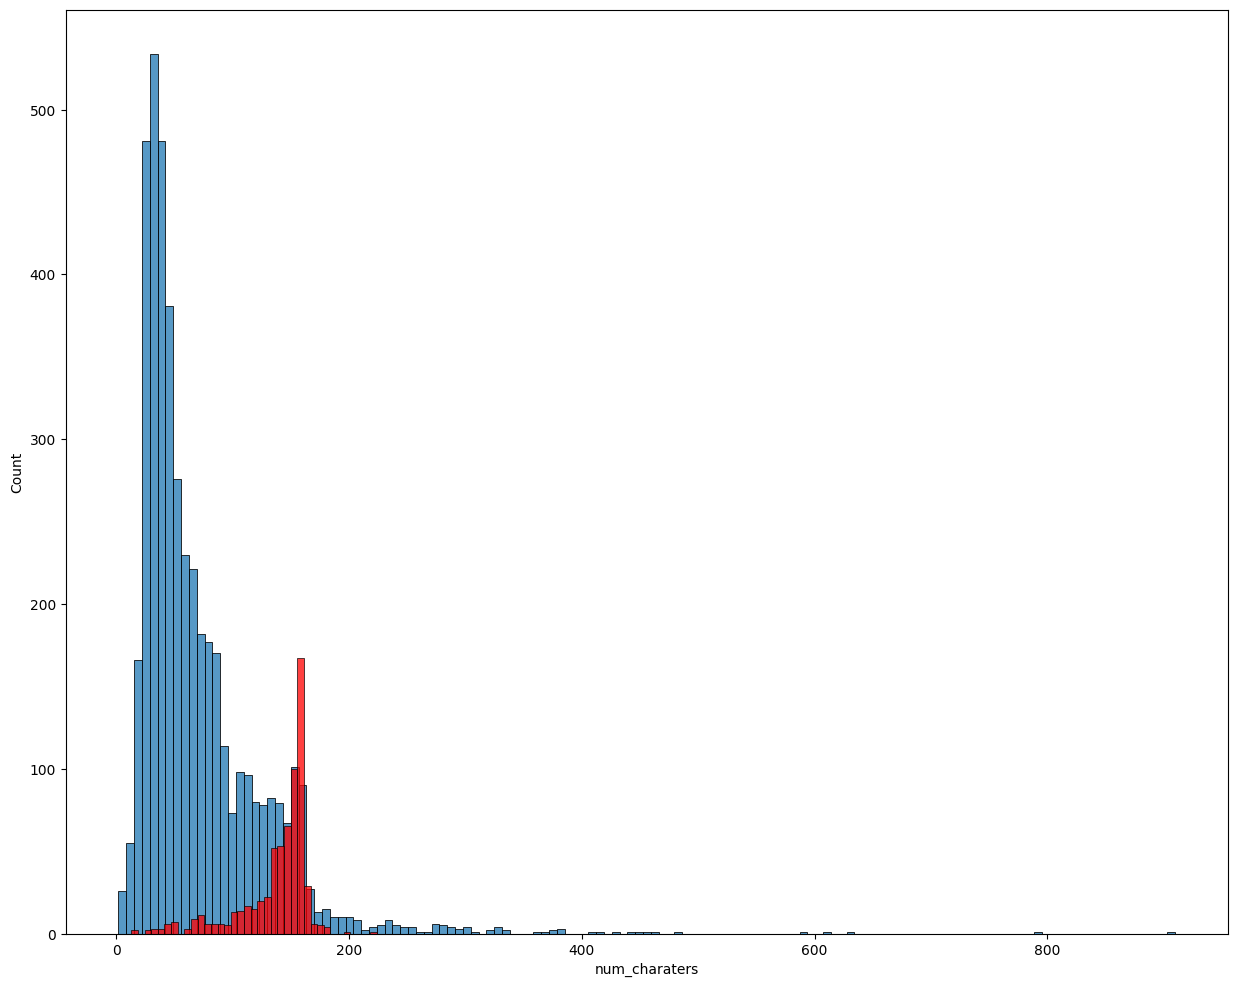

In [27]:
import seaborn as sns
plt.figure(figsize = (15,12))
sns.histplot(df[df['target'] == 0]['num_charaters'])
sns.histplot(df[df['target'] == 1]['num_charaters'], color = 'red')   #The purpose is to compare the number of characters in the two classes.

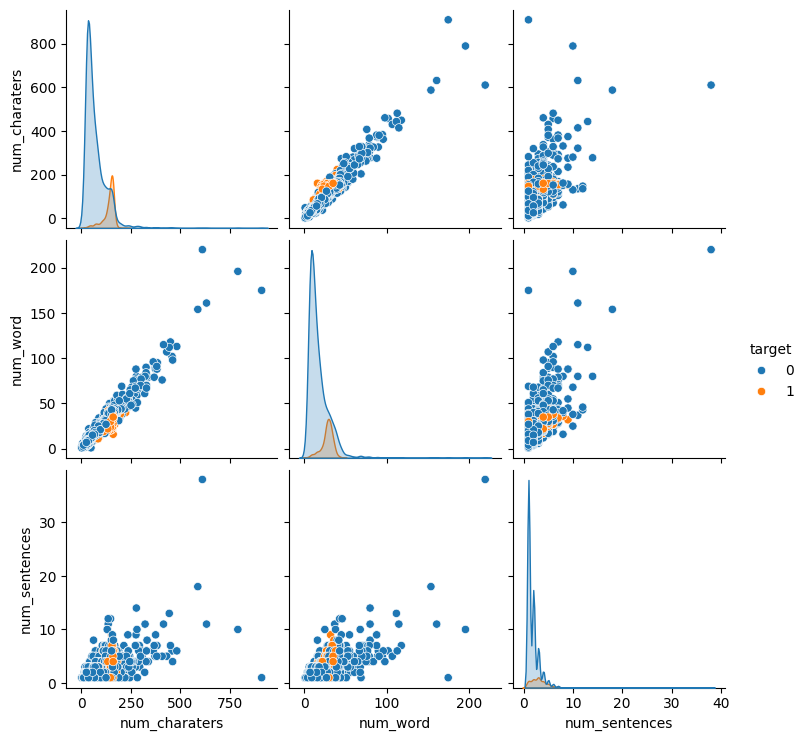

In [28]:
sns.pairplot(df, hue = "target")

<Axes: >

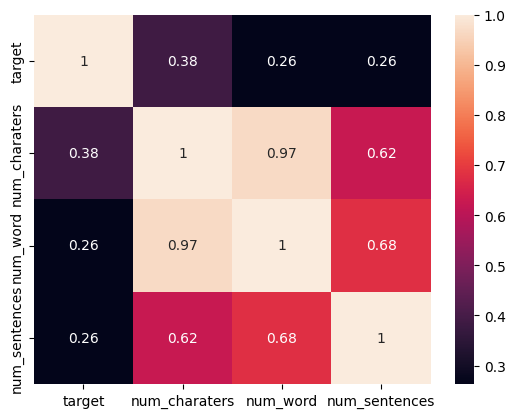

In [29]:
sns.heatmap(df[['target','num_charaters','num_word','num_sentences']].corr(),annot= True)

In [30]:
def transform_text(text):    #sns.pairplot(df, hue = "target")
  text = text.lower()
  return text

In [31]:
transform_text("HI THIS IS OUR FUCTIONS")

'hi this is our fuctions'

In [32]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)
  return text

In [33]:
transform_text("HI HOW ARE YOU?")

['hi', 'how', 'are', 'you', '?']

In [34]:
df['text']

,text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [35]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
from nltk.corpus import stopwords #These words are often removed because they may not provide much useful information.
from nltk.stem.porter import PorterStemmer   #This imports PorterStemmer, which reduces words to their basic/stem form.
import string #This imports Python's string module.

ps = PorterStemmer() #Here we create a PorterStemmer object.

def transform_text(text): #This creates a function called transform_text.
    # lowercase
    text = text.lower() #Make uppercase and lowercase versions of the same word consistent.

    # tokenization
    text = nltk.word_tokenize(text)

    # remove special characters
    text = [word for word in text if word.isalnum()] #This keeps only words/numbers that are alphanumeric.

    # remove stopwords and punctuation
    text = [word for word in text if word not in stopwords.words('english')] #This removes common English words.

    # stemming
    text = [ps.stem(word) for word in text]  #This converts words to their stem/root-like form.

    return " ".join(text) # combines tokenisec words into strings or combines them into one string with spaces:

**Piplines of preprocessing**ₙ
Lowercase → Tokenize → Remove special characters → Remove stopwords → Stem → Join

In [37]:
transform_text("Congratulations! You have won a $1000 prize.")  # call defined function: transform_text() function:
# it will tokenize, remove common words, first form of words, then combined into string ...

'congratul 1000 prize'

In [38]:
df['transformed_text'] = df['text'].apply(transform_text)
#This line applies your transform_text() function to every text message in the DataFrame and saves the cleaned text in a new column.

In [39]:
df[['text', 'transformed_text']].head()

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [40]:
df['transformed_text'][67] # So it gives you the cleaned/transformed text of row 67.

'urgent ur award complimentari trip eurodisinc trav aco entry41 claim txt di 87121 morefrmmob shracomorsglsuplt 10 ls1 3aj'

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer #These two lines are used to convert text into numbers so that a machine-learning model can understand it.
    #This imports TfidfVectorizer from Scikit-learn.
tfidf = TfidfVectorizer(max_features=3000)   #Keep at most 3,000 important/distinct features (words/terms) from the dataset.

In [42]:
X = tfidf.fit_transform(df['transformed_text']).toarray() #These two lines prepare your input (X) and output (y) for the machine-learning model.
     #First learns the important words/features from your text (fit) and then converts each text into numerical TF-IDF values (transform).
y = df['target']    #Converts the result into a normal NumPy array.

#So X contains the numerical representation of your text.

In [43]:
from sklearn.model_selection import train_test_split #Scikit-learn, a popular Python machine-learning library
                                             #model_selection = contains tools for preparing data for ML models
                                             #train_test_split = function used to divide data into training and testing sets.
                                             #randomly shuffles and divides your data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
                            #This means 20% of the data will be used for testing. The remaining 80% will be used for training.
                            # y_train contains the correct answers/targets corresponding to X_train,model uses these to learn the relationship between X and y.
                            #So every time you run the code, you get the same training and testing data. simply it fixes the training and testing data, we can use any other number for this purpose of fixing

In [44]:
from sklearn.naive_bayes import MultinomialNB  #This imports Multinomial Naive Bayes from Scikit-learn.

model = MultinomialNB()   #Here you are creating an empty model.

model.fit(X_train, y_train)   #Train the model using the training data.

MultinomialNB()

In [45]:
y_pred = model.predict(X_test)  #Use what you learned during training to predict the class of each email in X_test."

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
                                                    #This code checks how well your trained model is performing by comparing the actual answers (y_test) with the predicted answers (y_pred).
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
                                 #accuracy_score → overall percentage of correct predictions.
                                          #precision_score → how many emails predicted as spam were actually spam.
                                  #recall_score → how many actual spam emails the model successfully detected.
                                  #confusion_matrix → shows correct and incorrect predictions in detail.

Accuracy: 0.9729206963249516
Precision: 0.9915966386554622
Recall: 0.8137931034482758


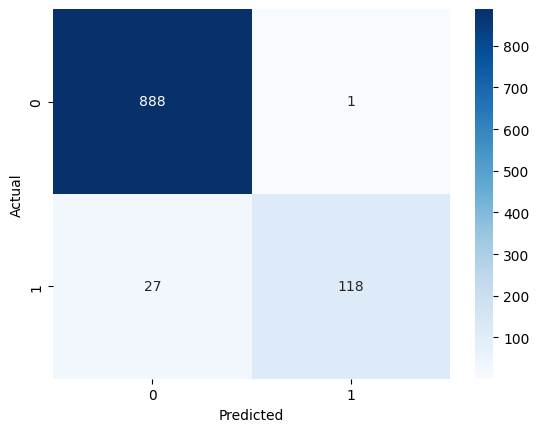

In [47]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),  # Creates the confusion matrix
    annot=True,                         # Shows values inside the boxes
    fmt='d',                            # Displays values as integers
    cmap='Blues'                        # Uses a blue color scheme
)

plt.xlabel("Predicted")                # Labels x-axis as Predicted
plt.ylabel("Actual")                   # Labels y-axis as Actual
plt.show()                             # Displays the heatmap

# details of below graph
# 888 samples were correctly classified as 0, Actual = 0(ham), Model predicted = 0(ham)
# 1 sample was incorrectly classified as 1. ,Actual = 0(ham), Model predicted = 1(spam)
# 27 samples were incorrectly classified as 0., Actual = 1(spam), Model predicted = 0(ham)
# 118 samples were correctly classified as 1., Actual = 1(spam), Model predicted = 1(spam)

In [48]:
message = ("I'll call you when I reach home.")  # Stores the message

transformed_message = transform_text(message)   # Cleans and preprocesses the message

message_vector = tfidf.transform([transformed_message]).toarray()  # Converts the message into TF-IDF numerical values

prediction = model.predict(message_vector)      # Uses the trained model to predict the class

print(prediction)                               # Prints the prediction (0 = Not Spam, 1 = Spam)

[0]


In [49]:
message = ("URGENT! You have been selected to win a FREE vacation!")  # Stores the message

transformed_message = transform_text(message)                         # Cleans and preprocesses the message

message_vector = tfidf.transform([transformed_message]).toarray()     # Converts the message into TF-IDF numerical values

prediction = model.predict(message_vector)                            # Uses the trained model to predict the class

print(prediction)                                                     # Prints the prediction (0 = Not Spam, 1 = Spam)

[1]


In [50]:
message = "Congratulations! You have won a free iPhone. Click now!"  # Stores the message

transformed_message = transform_text(message)                        # Cleans and preprocesses the message

message_vector = tfidf.transform([transformed_message]).toarray()    # Converts the message into TF-IDF numerical values

prediction = model.predict(message_vector)                           # Predicts whether the message is spam or not

print(prediction)                                                    # Prints the prediction (0 = Not Spam, 1 = Spam)

[1]


In [51]:
if prediction[0] == 1:   # Checks if the prediction is 1 (Spam)
    print("🚨 Spam")     # Prints Spam

else:                    # Runs when the prediction is not 1
    print("✅ Ham")      # Prints Ham (Not Spam)

🚨 Spam


In [52]:
message = "Hey, are we still meeting at 5 today?"

transformed_message = transform_text(message)
message_vector = tfidf.transform([transformed_message]).toarray()

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("🚨 Spam")
else:
    print("✅ Ham")

✅ Ham


**complete Spam/Ham classification project using Python, Pandas, NLTK, TF-IDF, and a machine-learning model.**

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: o

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                    transformed_text  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt may ...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  
(4135, 3000)
(1034, 3000)
Accuracy: 0.971953578336557
Precision: 0.9915254237288136
Recall: 0.8068965517241379


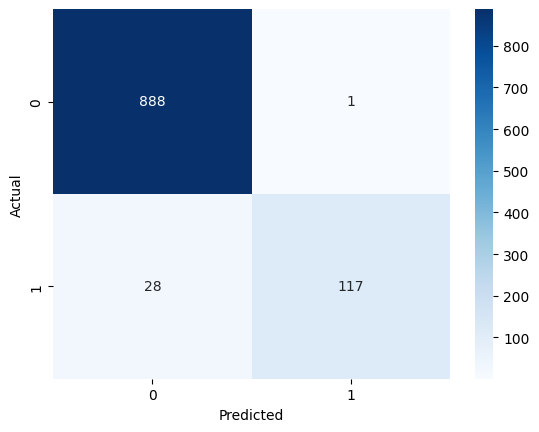

🚨 Spam


In [53]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)


# ============================================================
# 2. DOWNLOAD NLTK DATA
# ============================================================

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv("spam.csv", encoding="latin-1")  # Loads the dataset

print(df.head())  # Displays first five rows

print(df.shape)  # Shows number of rows and columns

print(df.info())  # Shows information about the dataset


# ============================================================
# 4. SELECT REQUIRED COLUMNS
# ============================================================

df = df[['v1', 'v2']]  # Selects label and message columns

df.columns = ['target', 'text']  # Renames columns


# ============================================================
# 5. CONVERT LABELS INTO NUMBERS
# ============================================================

df['target'] = df['target'].map({
    'ham': 0,
    'spam': 1
})  # Converts ham to 0 and spam to 1


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

print(df.isnull().sum())  # Checks for missing values


# ============================================================
# 7. REMOVE DUPLICATE MESSAGES
# ============================================================

df.drop_duplicates(inplace=True)  # Removes duplicate rows

print(df.shape)  # Shows dataset size after removing duplicates


# ============================================================
# 8. TEXT PREPROCESSING FUNCTION
# ============================================================

ps = PorterStemmer()  # Creates a stemming object

stop_words = set(stopwords.words('english'))  # Gets English stopwords


def transform_text(text):
    # Converts text into lowercase
    text = text.lower()

    # Breaks the sentence into individual words
    tokens = word_tokenize(text)

    # Keeps only alphabetic words
    tokens = [
        word for word in tokens
        if word.isalpha()
    ]

    # Removes stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Applies stemming
    tokens = [
        ps.stem(word)
        for word in tokens
    ]

    # Joins words back into a sentence
    return " ".join(tokens)


# ============================================================
# 9. APPLY TEXT PREPROCESSING
# ============================================================

df['transformed_text'] = df['text'].apply(
    transform_text
)  # Cleans every message


print(df[['text', 'transformed_text']].head())
# Displays original and cleaned messages


# ============================================================
# 10. SEPARATE INPUT AND OUTPUT
# ============================================================

X = df['transformed_text']  # Input messages

y = df['target']  # Output labels


# ============================================================
# 11. SPLIT DATA INTO TRAINING AND TESTING DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)  # 80% training and 20% testing


# ============================================================
# 12. TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    max_features=3000
)  # Creates TF-IDF vectorizer


X_train = tfidf.fit_transform(
    X_train
).toarray()  # Learns vocabulary and converts training text into numbers


X_test = tfidf.transform(
    X_test
).toarray()  # Converts testing text using the same vocabulary


print(X_train.shape)  # Shows training data dimensions

print(X_test.shape)  # Shows testing data dimensions


# ============================================================
# 13. CREATE MACHINE LEARNING MODEL
# ============================================================

model = MultinomialNB()
# Creates a Naive Bayes classification model


# ============================================================
# 14. TRAIN THE MODEL
# ============================================================

model.fit(
    X_train,
    y_train
)  # Trains the model using training data


# ============================================================
# 15. TEST THE MODEL
# ============================================================

y_pred = model.predict(
    X_test
)  # Predicts labels for test messages


# ============================================================
# 16. MODEL EVALUATION
# ============================================================

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)  # Calculates accuracy


print(
    "Precision:",
    precision_score(y_test, y_pred)
)  # Calculates precision


print(
    "Recall:",
    recall_score(y_test, y_pred)
)  # Calculates recall


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

sns.heatmap(
    confusion_matrix(y_test, y_pred),  # Creates confusion matrix
    annot=True,                         # Shows numbers inside boxes
    fmt='d',                            # Displays numbers as integers
    cmap='Blues'                        # Uses blue color scheme
)

plt.xlabel("Predicted")  # Labels x-axis
plt.ylabel("Actual")     # Labels y-axis
plt.show()               # Displays confusion matrix


# ============================================================
# 18. PREDICT A NEW MESSAGE
# ============================================================

message = "Congratulations! You have won a free iPhone. Click now!"
# Stores a new message


transformed_message = transform_text(
    message
)  # Cleans the new message


message_vector = tfidf.transform(
    [transformed_message]
).toarray()  # Converts message into TF-IDF numbers


prediction = model.predict(
    message_vector
)  # Predicts whether message is spam or ham


# ============================================================
# 19. DISPLAY FINAL PREDICTION
# ============================================================

if prediction[0] == 1:
    print("🚨 Spam")  # Prediction is spam

else:
    print("✅ Ham")  # Prediction is not spam

                    SPAM/HAM PROJECT
                           │
                           ▼
                    Load Dataset
                           │
                           ▼
                    Data Cleaning
                  ┌────────┴────────┐
                  │                 │
             Remove duplicates   Missing values
                  │
                  ▼
              Text Cleaning
                  │
       Lowercase → Tokenization
                  │
       Remove punctuation/stopwords
                  │
               Stemming
                  │
                  ▼
             TF-IDF Vectorizer
                  │
                  ▼
             Train/Test Split
                  │
          ┌───────┴────────┐
          ▼                ▼
       Training          Testing
          │                │
          ▼                ▼
     ML Model          Prediction
          │                │
          └───────┬────────┘
                  ▼
             Evaluation
                  │
        Accuracy / Precision
             / Recall
                  │
                  ▼
            New Message
                  │
                  ▼
          Spam or Ham **🚨✅**